In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import numpy as np
import os
from sklearn.utils import class_weight

In [2]:
data_dir = 'data'  # Replace with the path to your main directory
img_height = 224
img_width = 224
batch_size = 32
epochs = 10  # Adjust as needed
validation_split = 0.2  # Percentage of data for validation

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=validation_split  
)

In [4]:
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',  # Assuming you have subdirectories for each class
    subset='training',
    shuffle=True,
    seed=42
)

Found 4987 images belonging to 21 classes.


In [5]:
validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 1237 images belonging to 21 classes.


In [16]:
class_labels = list(train_generator.class_indices.keys())
num_classes = len(class_labels)
class_counts = np.bincount(train_generator.classes)

[  36   42   77 1882   84  519   13  106   61   61   13  183  724   77
  160   16   96  394   36  119  288]


In [7]:
total_samples = len(train_generator.classes)
weights = total_samples / (np.array(class_counts) + 1e-5)  # Adding small epsilon to avoid division by zero
class_weights = {i: weights[i] for i in range(num_classes)}
print("Calculated Class Weights:", class_weights)

Calculated Class Weights: {0: np.float64(138.5277392978502), 1: np.float64(118.7380669671269), 2: np.float64(64.76622535503567), 3: np.float64(2.649840581031665), 4: np.float64(59.36904055130469), 5: np.float64(9.608863013316705), 6: np.float64(383.6150895268542), 7: np.float64(47.04716537290893), 8: np.float64(81.75408495834672), 9: np.float64(81.75408495834672), 10: np.float64(383.6150895268542), 11: np.float64(27.25136463107297), 12: np.float64(6.888121451821527), 13: np.float64(64.76622535503567), 14: np.float64(31.168748051953248), 15: np.float64(311.68730519543425), 16: np.float64(51.94791125542591), 17: np.float64(12.657360084838578), 18: np.float64(138.5277392978502), 19: np.float64(41.907559503566425), 20: np.float64(17.315971620973208)}


In [8]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

In [9]:
for layer in base_model.layers:
    layer.trainable = False

In [10]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

In [11]:
model = Model(inputs=base_model.input, outputs=predictions)

In [12]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)  # Adjust learning rate as needed
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [13]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,  # Pass the calculated class weights here
    verbose=1
)


C:\Users\uzair\.conda\envs\ai-env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 300s 2s/step - accuracy: 0.4097 - loss: 2.0711 - val_accuracy: 0.5814 - val_loss: 1.3637
Epoch 2/10
  1/155 ━━━━━━━━━━━━━━━━━━━━ 1:28 578ms/step - accuracy: 0.7500 - loss: 1.0154

C:\Users\uzair\.conda\envs\ai-env\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


155/155 ━━━━━━━━━━━━━━━━━━━━ 54s 350ms/step - accuracy: 0.7500 - loss: 1.0154 - val_accuracy: 0.5691 - val_loss: 1.3653
Epoch 3/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 281s 2s/step - accuracy: 0.6004 - loss: 1.2672 - val_accuracy: 0.6299 - val_loss: 1.1678
Epoch 4/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 55s 352ms/step - accuracy: 0.5625 - loss: 1.2290 - val_accuracy: 0.6431 - val_loss: 1.1457
Epoch 5/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 281s 2s/step - accuracy: 0.6472 - loss: 1.0881 - val_accuracy: 0.6546 - val_loss: 1.0575
Epoch 6/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 53s 341ms/step - accuracy: 0.5312 - loss: 1.4101 - val_accuracy: 0.6686 - val_loss: 1.0497
Epoch 7/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 258s 2s/step - accuracy: 0.6692 - loss: 1.0201 - val_accuracy: 0.6834 - val_loss: 0.9721
Epoch 8/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 45s 286ms/step - accuracy: 0.5938 - loss: 1.2358 - val_accuracy: 0.6867 - val_loss: 0.9696
Epoch 9/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 235s 2s/step - accuracy: 0.6908 - loss: 0.9331 - val_accurac

In [14]:
loss, accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.7962 - loss: 0.6769
Validation Loss: 0.9450
Validation Accuracy: 0.6669


In [18]:
model.save('models/fabric_pattern_model_1.h5')

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

In [23]:
model_path = "models/fabric_pattern_model_1.h5"

In [24]:
model_1 = tf.keras.models.load_model(model_path)

In [28]:
# --- 3. Make Predictions on the Validation Set ---
print("Making predictions on the validation set...")
# Predict probabilities for each class
y_pred_probs = model_1.predict(validation_generator, steps=validation_generator.samples // batch_size + 1)
# Convert probabilities to class labels (index of the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels from the generator
# The generator provides labels in the order it processes the data
y_true = validation_generator.classes

Making predictions on the validation set...
39/39 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step


In [30]:
class_names = list(validation_generator.class_indices.keys())
print("\n--- Classification Report ---")
# target_names: provides meaningful labels for the report
# digits: number of decimal places for floating point values
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


--- Classification Report ---
              precision    recall  f1-score   support

     Acrylic     1.0000    0.6250    0.7692         8
    Chenille     1.0000    0.3000    0.4615        10
    Corduroy     0.7368    0.7368    0.7368        19
      Cotton     0.6382    0.9234    0.7548       470
       Crepe     0.6667    0.3000    0.4138        20
       Denim     0.8689    0.8217    0.8446       129
        Felt     0.0000    0.0000    0.0000         3
      Fleece     0.8333    0.5769    0.6818        26
     Leather     1.0000    0.1333    0.2353        15
       Linen     1.0000    0.4000    0.5714        15
         Lut     0.0000    0.0000    0.0000         3
       Nylon     0.5938    0.4222    0.4935        45
   Polyester     0.6765    0.5111    0.5823       180
       Satin     0.6667    0.1053    0.1818        19
        Silk     0.4906    0.6500    0.5591        40
       Suede     0.0000    0.0000    0.0000         4
  Terrycloth     0.9500    0.7917    0.8636       

C:\Users\uzair\.conda\envs\ai-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\uzair\.conda\envs\ai-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\uzair\.conda\envs\ai-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [31]:
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
print(cm)


--- Confusion Matrix ---
[[  5   0   0   2   0   0   0   0   0   0   0   0   1   0   0   0   0   0
    0   0   0]
 [  0   3   0   3   0   0   0   0   0   0   1   0   2   0   0   0   0   0
    1   0   0]
 [  0   0  14   4   0   0   0   0   0   0   0   0   0   0   0   0   0   1
    0   0   0]
 [  0   0   3 434   0   7   0   0   0   0   0   3  12   0   2   0   0   5
    0   0   4]
 [  0   0   0   6   6   2   0   0   0   0   0   0   4   1   0   0   0   0
    0   0   1]
 [  0   0   0  22   0 106   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   1]
 [  0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0   0   2
    0   0   0]
 [  0   0   1   8   0   0   0  15   0   0   0   0   0   0   0   0   0   2
    0   0   0]
 [  0   0   0   8   0   0   0   0   2   0   0   0   3   0   0   0   0   1
    0   0   1]
 [  0   0   0   9   0   0   0   0   0   6   0   0   0   0   0   0   0   0
    0   0   0]
 [  0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0   0   2
    0   0 

  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp310-cp310-win_amd64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 2.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.1 MB 3.0 MB/s eta 0:00:03
   --------- ------------------------------ 1.8/8.1 MB 3.4 MB/s eta 0:00:02
   ------------- -------------------------- 2.6/8.1 MB 3.3 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.1 MB 3.2 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 2.9 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 2.9 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 2.4 MB/s eta 0:00:02
   ------------------- -------------------

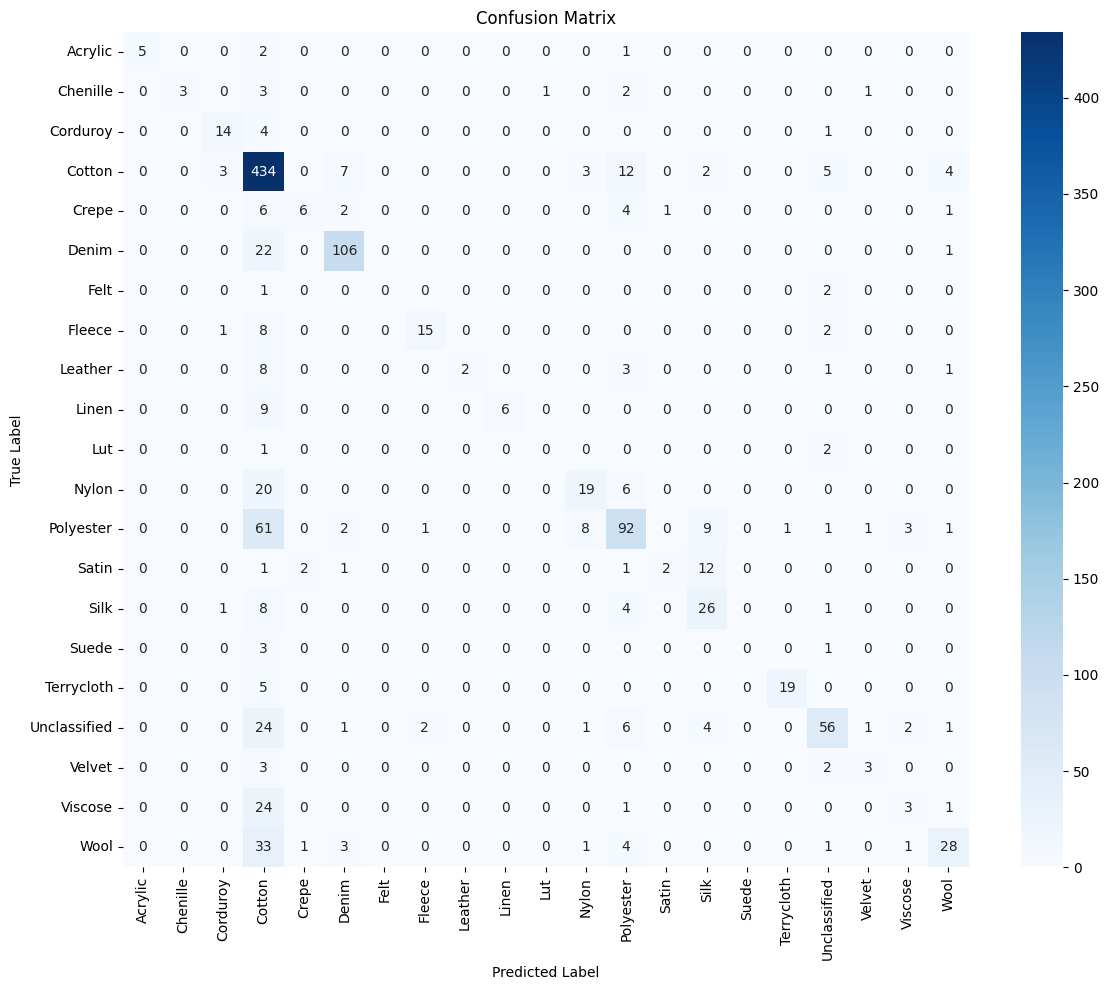

In [32]:
%pip install matplotlib
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns
# Plotting the confusion matrix for better visualization
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()